In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
pd.set_option('display.max_columns',None)
import warnings
warnings.filterwarnings('ignore')

In [2]:
train_labels = pd.read_csv('train_labels.csv') # it has two column (building_id & damage_grade)
train_values = pd.read_csv('train_values.csv') # it has many column (buidling_id & and others)


In [3]:
display(train_labels.shape)
display(train_values.shape)

(260601, 2)

(260601, 39)

In [4]:
display(train_labels.info())
print('==================')
display(train_values.info())

<class 'pandas.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 2 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   building_id   260601 non-null  int64
 1   damage_grade  260601 non-null  int64
dtypes: int64(2)
memory usage: 4.0 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 260601 entries, 0 to 260600
Data columns (total 39 columns):
 #   Column                                  Non-Null Count   Dtype
---  ------                                  --------------   -----
 0   building_id                             260601 non-null  int64
 1   geo_level_1_id                          260601 non-null  int64
 2   geo_level_2_id                          260601 non-null  int64
 3   geo_level_3_id                          260601 non-null  int64
 4   count_floors_pre_eq                     260601 non-null  int64
 5   age                                     260601 non-null  int64
 6   area_percentage                         260601 non-null  int64
 7   height_percentage                       260601 non-null  int64
 8   land_surface_condition                  260601 non-null  str  
 9   foundation_type                         260601 non-null  str  
 10  roof_type                               260601 non-null  str  
 11  ground_floo

None

In [5]:
# display(pd.merge(train_labels, train_values , on='building_id' ,how = 'inner').info())

df = pd.merge(train_labels, train_values , on='building_id' ,how = 'inner')


In [6]:
df.shape

(260601, 40)

In [7]:
df.head(5)

,building_id,damage_grade,geo_level_1_id,geo_level_2_id,geo_level_3_id,count_floors_pre_eq,age,area_percentage,height_percentage,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,has_superstructure_adobe_mud,has_superstructure_mud_mortar_stone,has_superstructure_stone_flag,has_superstructure_cement_mortar_stone,has_superstructure_mud_mortar_brick,has_superstructure_cement_mortar_brick,has_superstructure_timber,has_superstructure_bamboo,has_superstructure_rc_non_engineered,has_superstructure_rc_engineered,has_superstructure_other,legal_ownership_status,count_families,has_secondary_use,has_secondary_use_agriculture,has_secondary_use_hotel,has_secondary_use_rental,has_secondary_use_institution,has_secondary_use_school,has_secondary_use_industry,has_secondary_use_health_post,has_secondary_use_gov_office,has_secondary_use_use_police,has_secondary_use_other
0,802906,3,6,487,12198,2,30,6,5,t,r,n,f,q,t,d,1,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
1,28830,2,8,900,2812,2,10,8,7,o,r,n,x,q,s,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
2,94947,3,21,363,8973,2,10,5,5,t,r,n,f,x,t,d,0,1,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
3,590882,2,22,418,10694,2,10,6,5,t,r,n,f,x,s,d,0,1,0,0,0,0,1,1,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0
4,201944,3,11,131,1488,3,30,8,9,t,r,n,f,x,s,d,1,0,0,0,0,0,0,0,0,0,0,v,1,0,0,0,0,0,0,0,0,0,0,0


In [8]:
df.dtypes

building_id                               int64
damage_grade                              int64
geo_level_1_id                            int64
geo_level_2_id                            int64
geo_level_3_id                            int64
count_floors_pre_eq                       int64
age                                       int64
area_percentage                           int64
height_percentage                         int64
land_surface_condition                      str
foundation_type                             str
roof_type                                   str
ground_floor_type                           str
other_floor_type                            str
position                                    str
plan_configuration                          str
has_superstructure_adobe_mud              int64
has_superstructure_mud_mortar_stone       int64
has_superstructure_stone_flag             int64
has_superstructure_cement_mortar_stone    int64
has_superstructure_mud_mortar_brick     

### Statistics - ALL

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
building_id,260601.0,525675.482773,304544.999032,4.0,261190.0,525757.0,789762.0,1052934.0
damage_grade,260601.0,2.238272,0.611814,1.0,2.0,2.0,3.0,3.0
geo_level_1_id,260601.0,13.900353,8.033617,0.0,7.0,12.0,21.0,30.0
geo_level_2_id,260601.0,701.074685,412.710734,0.0,350.0,702.0,1050.0,1427.0
geo_level_3_id,260601.0,6257.876148,3646.369645,0.0,3073.0,6270.0,9412.0,12567.0
count_floors_pre_eq,260601.0,2.129723,0.727665,1.0,2.0,2.0,2.0,9.0
age,260601.0,26.535029,73.565937,0.0,10.0,15.0,30.0,995.0
area_percentage,260601.0,8.018051,4.392231,1.0,5.0,7.0,9.0,100.0
height_percentage,260601.0,5.434365,1.918418,2.0,4.0,5.0,6.0,32.0
has_superstructure_adobe_mud,260601.0,0.088645,0.284231,0.0,0.0,0.0,0.0,1.0


### Statistics - Categorical Columns

In [10]:
df.describe(include = 'object').T

,count,unique,top,freq
land_surface_condition,260601,3,t,216757
foundation_type,260601,5,r,219196
roof_type,260601,3,n,182842
ground_floor_type,260601,5,f,209619
other_floor_type,260601,4,q,165282
position,260601,4,s,202090
plan_configuration,260601,10,d,250072
legal_ownership_status,260601,4,v,250939


In [11]:
df.isnull().sum().sum()

np.int64(0)

There is no missing value

In [12]:
df.duplicated().sum()

np.int64(0)

### THere is no duplicate in the data

In [13]:
df.damage_grade.value_counts().sort_index()

damage_grade
1     25124
2    148259
3     87218
Name: count, dtype: int64

In [14]:
df.age.sort_values().unique()

array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
       130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190,
       195, 200, 995])

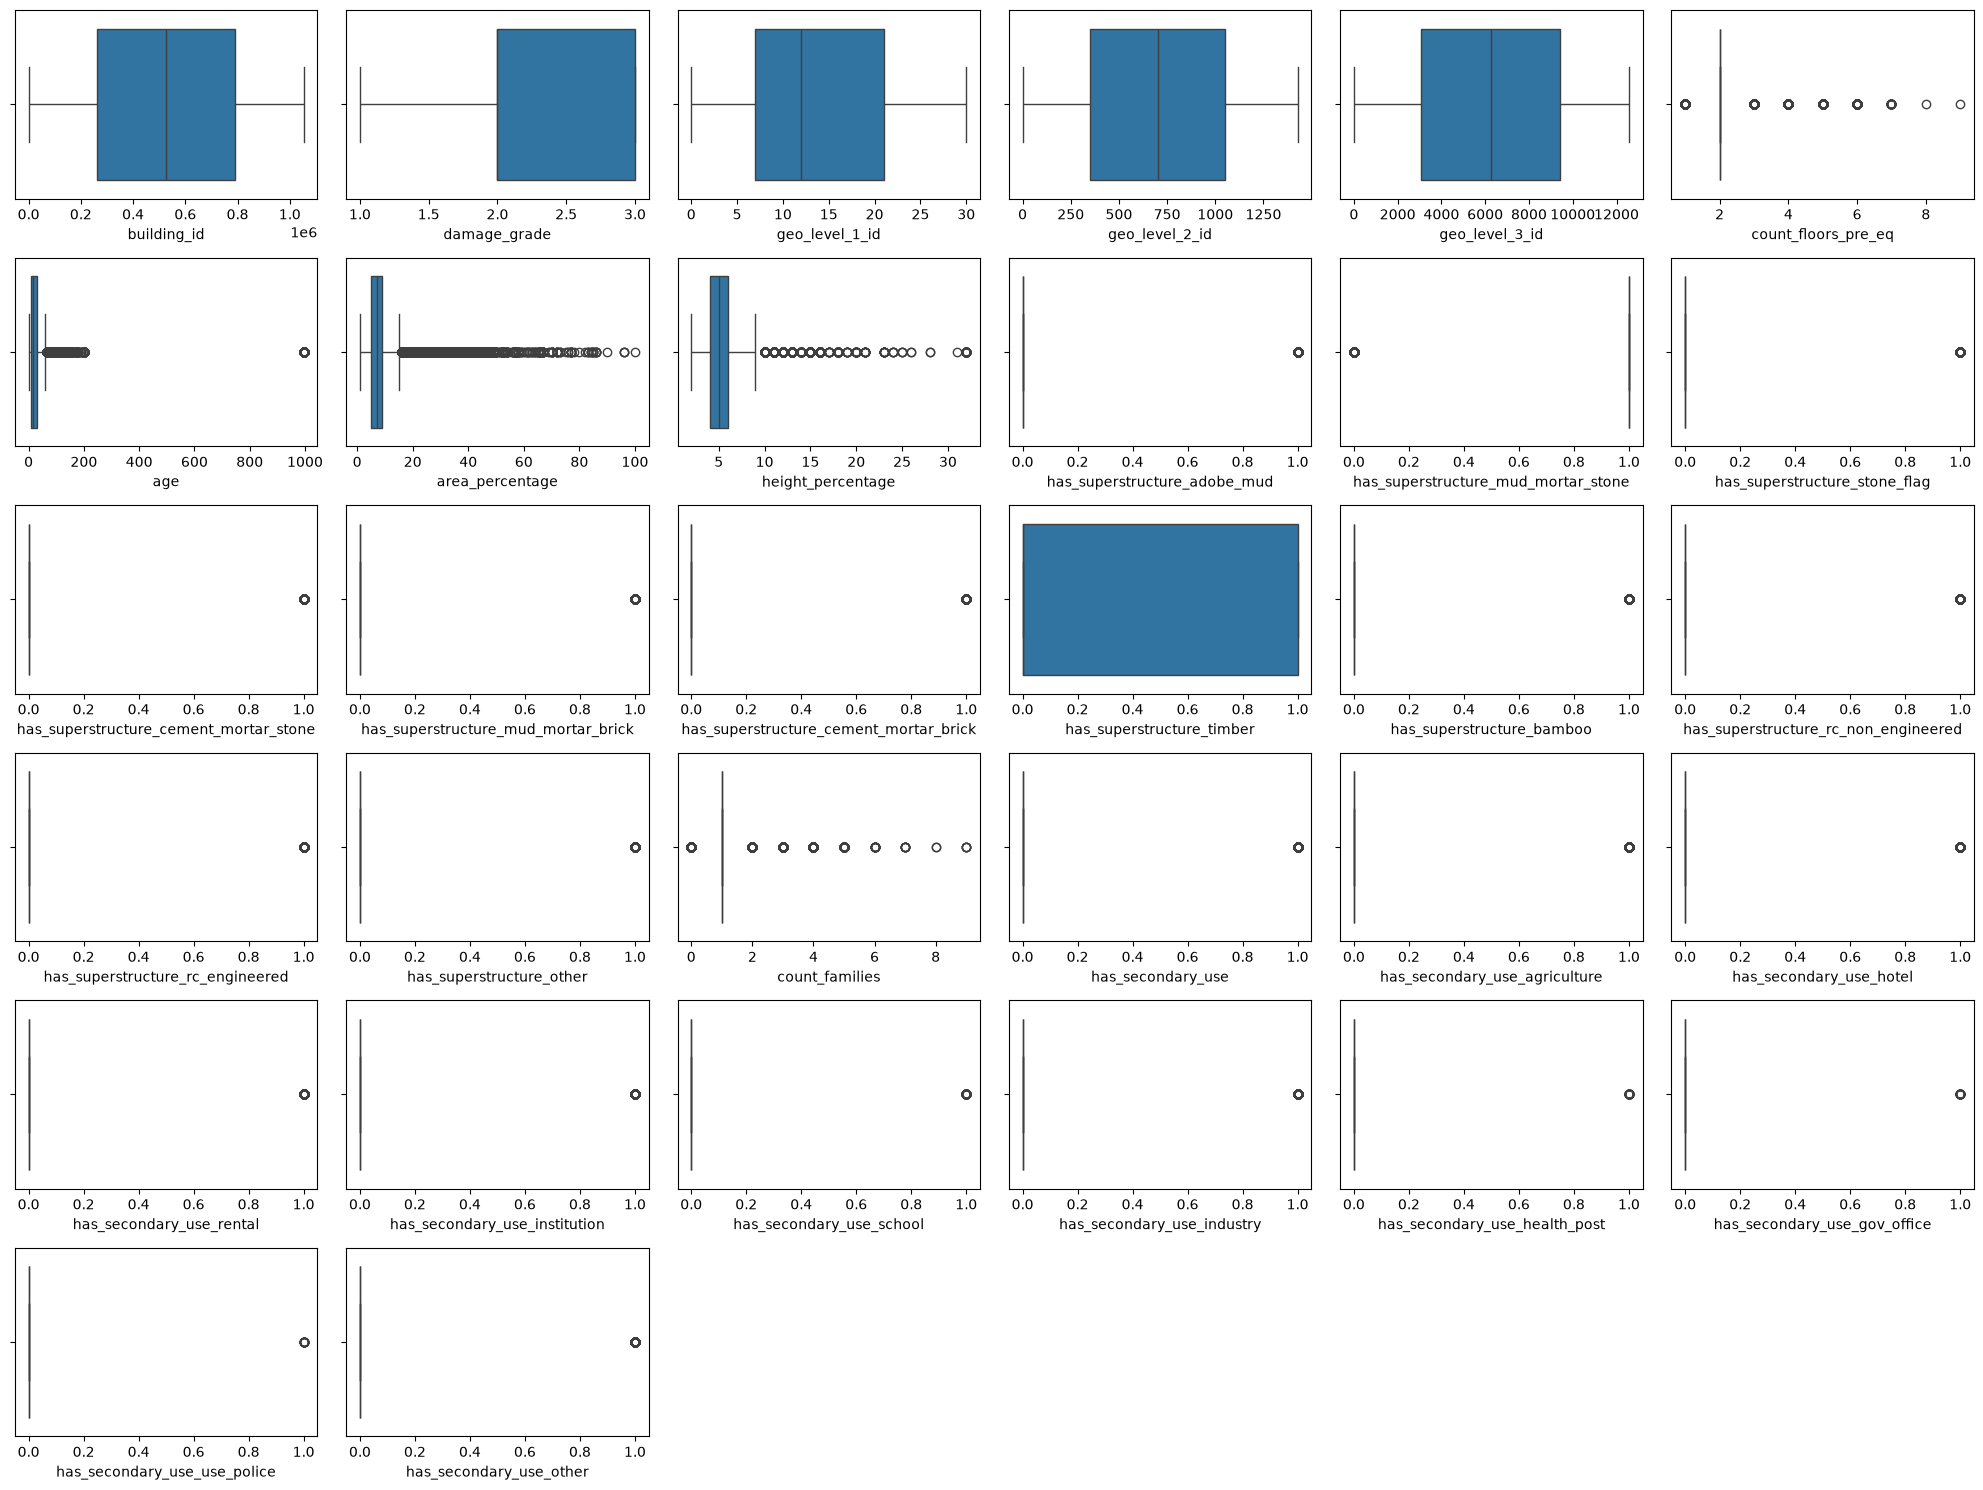

In [15]:
import seaborn as sns

plt.figure(figsize=(20,15))

numeric_cols = df.select_dtypes(include = np.number)
# print(numeric_cols.columns)
for i, col in enumerate(numeric_cols.columns):
    plt.subplot(6, 6, i+1)
    sns.boxplot(x = df[col])

plt.tight_layout()
plt.show()

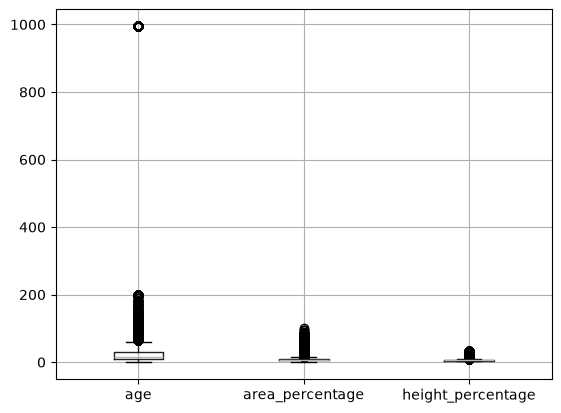

In [16]:
df.boxplot(column=['age','area_percentage','height_percentage'])
plt.show()

In [17]:
(df['age']== 995).sum()

np.int64(1390)

In [18]:
(df['age'] == 995).sum()




np.int64(1390)

In [19]:
normal_age_median = df[df['age'] != 995]['age'].median()

In [20]:
df['age'] = df['age'].replace(995, normal_age_median)

display(df['age'].max())

200

### age of any place can be upto 200 

---------------

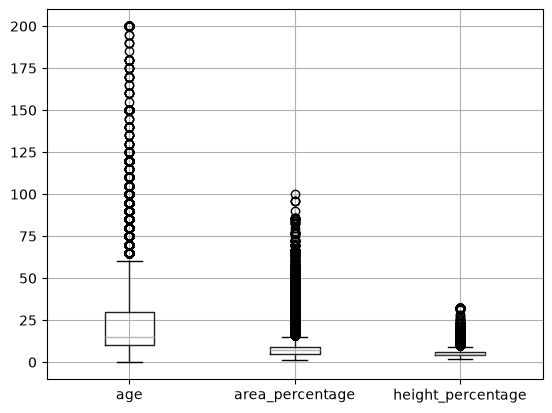

In [21]:
df.boxplot(column=['age','area_percentage','height_percentage'])
plt.show()

### capping 'area_percentage' and 'height_percentage'

In [26]:
df[col].unique().sum()

np.int64(44)

In [23]:
for col in ['area_percentage', 'height_percentage']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3- Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    num_outlier = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    print(f'{col} : capping {num_outlier} outlier to range [{lower_bound:.2f}, {upper_bound:.2f}]')
    df[col] = df[col].clip(lower=lower_bound, upper= upper_bound)

area_percentage : capping 13557 outlier to range [-1.00, 15.00]
height_percentage : capping 7843 outlier to range [1.00, 9.00]


In [28]:
df.select_dtypes(exclude = np.number).columns

Index(['land_surface_condition', 'foundation_type', 'roof_type',
       'ground_floor_type', 'other_floor_type', 'position',
       'plan_configuration', 'legal_ownership_status'],
      dtype='str')

In [29]:
categorical_columns = df.select_dtypes(exclude = np.number).columns


    

## Target 

In [30]:
df['damage_grade'] = df['damage_grade'].astype(int)

In [32]:
# print(df.dtypes)

## EDA

#### Univariate Analysis

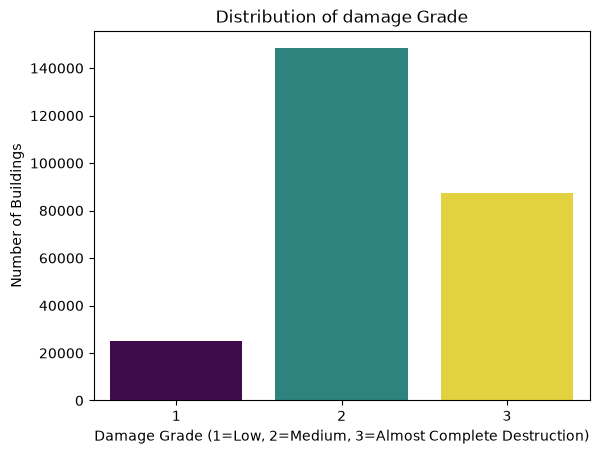

In [43]:
# Damage grade distribution (target)

sns.countplot(data = df, x = 'damage_grade', palette='viridis', hue= 'damage_grade', legend = False)
plt.title('Distribution of damage Grade')
plt.xlabel('Damage Grade (1=Low, 2=Medium, 3=Almost Complete Destruction)')
plt.ylabel('Number of Buildings')
plt.show()

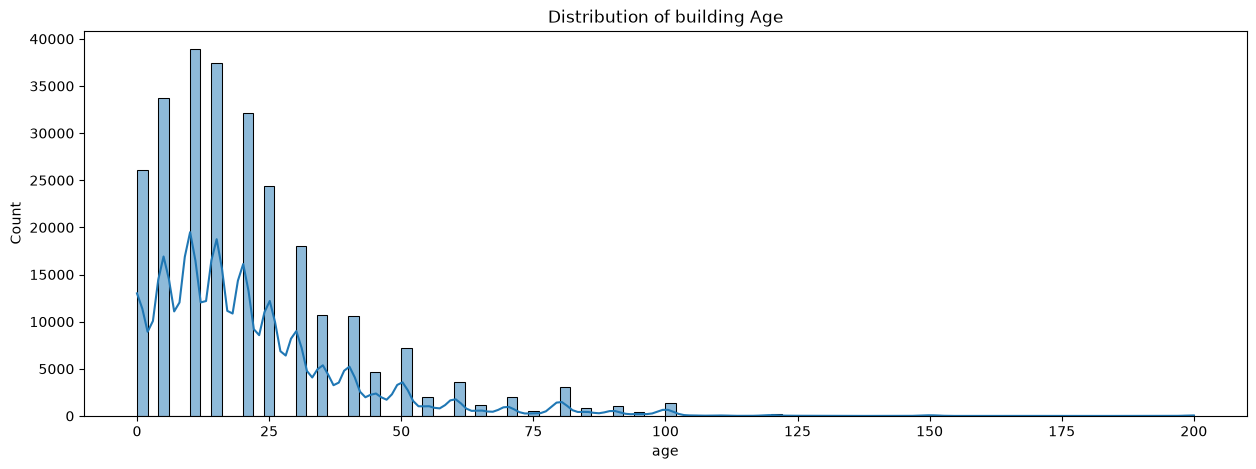

In [62]:
# Distribution of building age
plt.figure(figsize=(15,6))
sns.histplot(data = df, x = 'age', bins = 100,kde = True)
plt.title('Distribution of building Age')
plt.xlabel('age')
plt.ylabel('Number of Buildings')

plt.show()

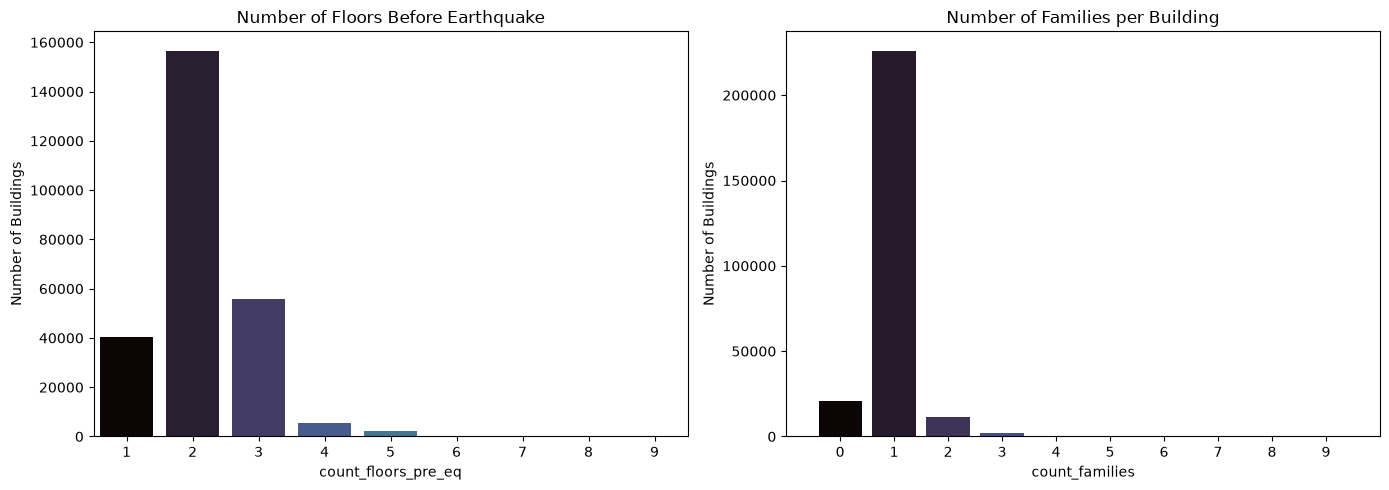

In [74]:
# Distribution of number of floors and count of families
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.countplot(x="count_floors_pre_eq", data=df, ax=axes[0], palette="mako", hue="count_floors_pre_eq", legend=False)
axes[0].set_title("Number of Floors Before Earthquake")
axes[0].set_ylabel('Number of Buildings')




sns.countplot(x="count_families", data=df, ax=axes[1], palette="mako", hue="count_families", legend=False)
axes[1].set_title("Number of Families per Building")
axes[1].set_xlim(-1, 10)  # limit view to common range
axes[1].set_ylabel('Number of Buildings')


plt.tight_layout()
plt.show()

### Bivariate Analysis - structural feature vs damage

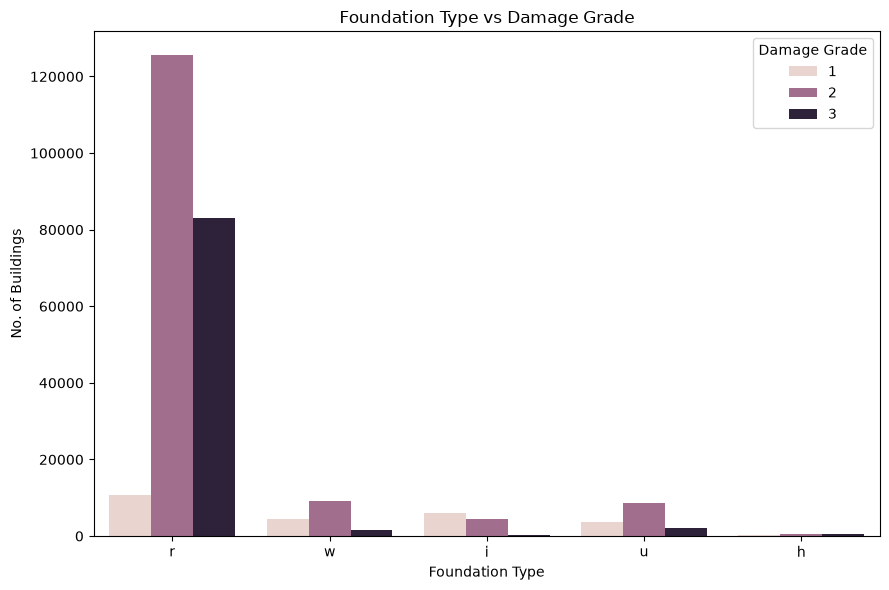

In [82]:
# Foundation Type vs Damage Grade

plt.figure(figsize=(9,6))

sns.countplot(data=df, x = 'foundation_type', hue='damage_grade')
plt.title('Foundation Type vs Damage Grade')
plt.xlabel('Foundation Type')
plt.ylabel('No. of Buildings')
plt.legend(title = 'Damage Grade')

plt.tight_layout()
plt.show()

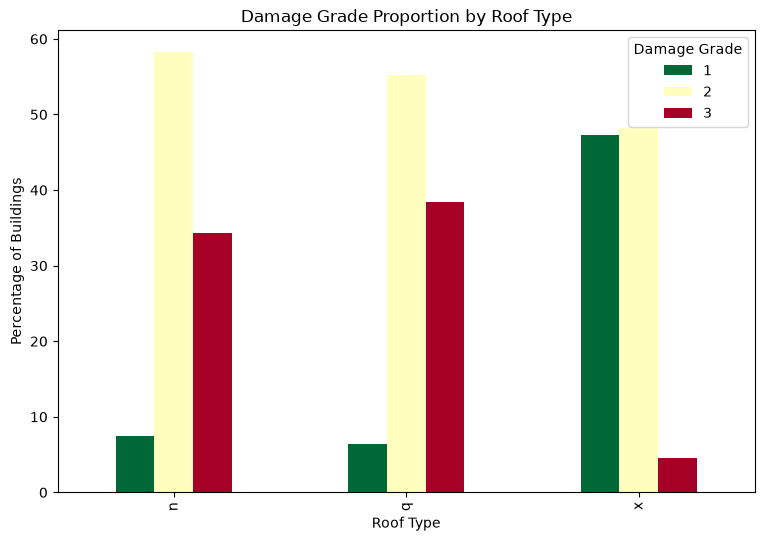

In [84]:
#Roof Type vs damage grade
# Roof type vs damage grade (proportion within each roof type, more interpretable than raw counts)
roof_damage_pct = pd.crosstab(df["roof_type"], df["damage_grade"], normalize="index") * 100
roof_damage_pct.plot(kind="bar", colormap="RdYlGn_r", figsize=(9, 6))
plt.title("Damage Grade Proportion by Roof Type")
plt.ylabel("Percentage of Buildings")
plt.xlabel("Roof Type")
plt.legend(title="Damage Grade")
plt.show()

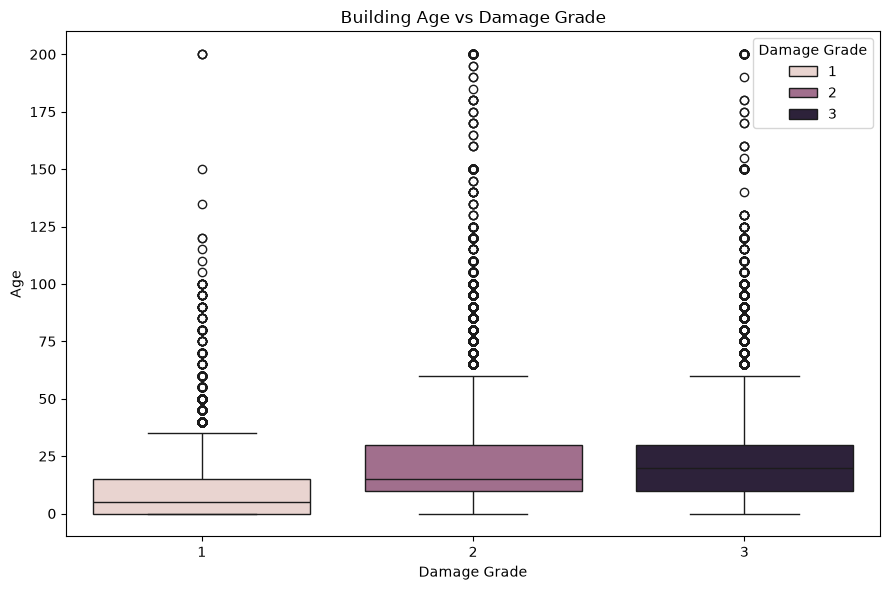

In [97]:
# building age vs damage age

plt.figure(figsize=(9,6))

sns.boxplot(data=df, y = 'age', x='damage_grade', hue = 'damage_grade')
plt.title('Building Age vs Damage Grade')

plt.ylabel('Age')
plt.xlabel('Damage Grade')
plt.legend(title = 'Damage Grade')
plt.tight_layout()
plt.show()